### Introducción

Este proyecto aplica un análisis RFM (Recency, Frequency y Monetary) para segmentar clientes según su comportamiento de compra.

El objetivo es identificar los grupos de clientes con mayor valor para el negocio, detectar clientes con potencial de crecimiento o reactivación y proponer acciones comerciales específicas para cada perfil.

El análisis utiliza el dataset Online Retail, que contiene transacciones de una empresa británica de comercio online. El proceso incluye la revisión y limpieza de los datos, el cálculo de las métricas RFM, la asignación de scores, la segmentación de clientes y el análisis de los resultados mediante visualizaciones.

Enlace de descarga del dataset:
https://archive.ics.uci.edu/dataset/352/online%2Bretail?

In [5]:
import pandas as pd

datos=pd.read_excel("OnlineRetail.xlsx")

datos.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [6]:
datos.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom


Comenzamos con una exploración inicial del dataset para conocer su estructura, tipos de datos, valores nulos, duplicados y posibles inconsistencias

In [8]:
datos.shape

(541909, 8)

In [9]:
datos.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

In [10]:
datos.duplicated().sum()

np.int64(5268)

In [11]:
datos[datos.duplicated(keep=False)].sort_values(by=datos.columns.tolist()).head(6)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom


In [12]:
datos.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [13]:
datos["Quantity"].max()

80995

In [14]:
datos["Quantity"].min()

-80995

In [15]:
datos["UnitPrice"].max()

38970.0

In [16]:
datos["UnitPrice"].min()

-11062.06

In [17]:
datos["CustomerID"].max()

18287.0

In [18]:
datos["CustomerID"].min()

12346.0

In [19]:
sorted(datos["Country"].unique())

['Australia',
 'Austria',
 'Bahrain',
 'Belgium',
 'Brazil',
 'Canada',
 'Channel Islands',
 'Cyprus',
 'Czech Republic',
 'Denmark',
 'EIRE',
 'European Community',
 'Finland',
 'France',
 'Germany',
 'Greece',
 'Hong Kong',
 'Iceland',
 'Israel',
 'Italy',
 'Japan',
 'Lebanon',
 'Lithuania',
 'Malta',
 'Netherlands',
 'Norway',
 'Poland',
 'Portugal',
 'RSA',
 'Saudi Arabia',
 'Singapore',
 'Spain',
 'Sweden',
 'Switzerland',
 'USA',
 'United Arab Emirates',
 'United Kingdom',
 'Unspecified']

### Exploración inicial

- El dataset contiene 541.909 filas y 8 columnas.
- CustomerID se ha importado como float64, probablemente debido a la presencia de valores nulos. Al tratarse de un identificador, conviene convertirlo posteriormente a un tipo más adecuado una vez gestionados dichos nulos.
- Se detectan 5.268 filas completamente duplicadas, que deberán eliminarse para evitar contabilizar transacciones repetidas.
- La columna Description contiene 1.454 valores nulos (0,2 % del dataset), mientras que CustomerID presenta 135.080 valores nulos (25 %).
- Las columnas Quantity y UnitPrice contienen valores negativos, por lo que es necesario revisar su significado antes de decidir cómo tratarlos.
- En Country no se observan variantes evidentes del mismo país debidas a diferencias de escritura.

A continuación, se revisa con más detalle la distribución de Quantity y UnitPrice, especialmente los valores negativos e iguales a 0, antes de aplicar las reglas de limpieza.


In [22]:
(datos["Quantity"]<0).sum()

np.int64(10624)

In [23]:
(datos["Quantity"]==0).sum()

np.int64(0)

In [24]:
(datos["Quantity"]>0).sum()

np.int64(531285)

In [25]:
(datos["UnitPrice"]<0).sum()

np.int64(2)

In [26]:
(datos["UnitPrice"]==0).sum()

np.int64(2515)

In [27]:
(datos["UnitPrice"]>0).sum()

np.int64(539392)

In [29]:
datos[datos["Quantity"]<0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397.0,United Kingdom
541541,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311.0,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom


In [30]:
datos[datos["UnitPrice"]<0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


In [33]:
datos[datos["UnitPrice"]==0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
536981,581234,72817,NaN,27,2011-12-08 10:33:00,0.0,NaN,United Kingdom
538504,581406,46000M,POLYESTER FILLER PAD 45x45cm,240,2011-12-08 13:58:00,0.0,NaN,United Kingdom
538505,581406,46000S,POLYESTER FILLER PAD 40x40cm,300,2011-12-08 13:58:00,0.0,NaN,United Kingdom
538554,581408,85175,NaN,20,2011-12-08 14:06:00,0.0,NaN,United Kingdom


### Revisión de valores anómalos
- En Quantity se identifican 10.624 valores negativos. No existen valores iguales a cero y se observan 531.285 valores positivos.
- En UnitPrice se detectan 2 valores negativos, asociados a la descripción Adjust bad debt, además de 2.515 registros con precio igual a cero y 539.392 valores positivos.

Se definen las siguientes reglas de limpieza para el análisis RFM:
- Excluir registros con Quantity <= 0.
- Excluir registros con UnitPrice <= 0.
- Excluir registros con CustomerID nulo.
- Eliminar filas completamente duplicadas.

El objetivo del análisis RFM es estudiar el comportamiento de compra de clientes identificados. Por ello, las transacciones sin cliente asociado o sin un importe de venta positivo no resultan adecuadas para calcular recencia, frecuencia y valor monetario. La eliminación de duplicados evita además contabilizar una misma transacción más de una vez.

In [35]:
datoslimpios=datos.copy()

In [82]:
datoslimpios=datoslimpios.drop_duplicates(keep="first")
datoslimpios=datoslimpios[(datoslimpios["Quantity"]>0)&(datoslimpios["UnitPrice"]>0)&(~datoslimpios["CustomerID"].isna())]
datoslimpios["CustomerID"] = datoslimpios["CustomerID"].astype(int)
datoslimpios.shape

(392692, 9)

Tras aplicar las reglas de limpieza, el dataset se reduce de 541.909 a 392.692 registros, conservando únicamente las transacciones válidas para el análisis RFM. Realizamos una pequeña comprobación:

In [83]:
datoslimpios.duplicated().sum()

np.int64(0)

In [84]:
datoslimpios.isna().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalPrice     0
dtype: int64

In [85]:
datoslimpios.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalPrice
count,392692.000000,392692,392692.000000,392692.000000,392692.000000
mean,13.119702,2011-07-10 19:13:07.771892480,3.125914,15287.843865,22.631500
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000
25%,2.000000,2011-04-07 11:12:00,1.250000,13955.000000,4.950000
50%,6.000000,2011-07-31 12:02:00,1.950000,15150.000000,12.450000
75%,12.000000,2011-10-20 12:53:00,3.750000,16791.000000,19.800000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.600000
std,180.492832,NaN,22.241836,1713.539549,311.099224


In [86]:
datoslimpios["CustomerID"].nunique()

4338

### Construcción del análisis RFM
A partir del dataset limpio, se calculan las tres métricas principales del análisis RFM: recencia, frecuencia y valor monetario para cada cliente.

In [87]:
datoslimpios["TotalPrice"]=datoslimpios["Quantity"]*datoslimpios["UnitPrice"]

In [88]:
rfm=datoslimpios.groupby("CustomerID",as_index=False).agg(last_purchase=("InvoiceDate","max"),frequency=("InvoiceNo","nunique"),total_amount=("TotalPrice","sum"))

In [89]:
rfm.head(5)

,CustomerID,last_purchase,frequency,total_amount
0,12346,2011-01-18 10:01:00,1,77183.60
1,12347,2011-12-07 15:52:00,7,4310.00
2,12348,2011-09-25 13:13:00,4,1797.24
3,12349,2011-11-21 09:51:00,1,1757.55
4,12350,2011-02-02 16:01:00,1,334.40


Para calcular Recency, se utiliza como fecha de referencia el día posterior a la última compra registrada en el dataset, es decir, el 10 de diciembre de 2011.

In [90]:
rfm["Recency"]=(pd.Timestamp("2011-12-10")-rfm["last_purchase"].dt.normalize()).dt.days

Hacemos una pequeña comprobación de valores únicos

In [91]:
rfm["frequency"].sort_values().unique()

array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  37,  38,  39,  41,
        44,  45,  46,  47,  48,  50,  51,  55,  57,  60,  62,  63,  73,
        86,  91,  93,  97, 124, 201, 209])

In [92]:
rfm["Recency"].sort_values().unique()

array([  1,   2,   3,   4,   5,   6,   8,   9,  10,  11,  12,  13,  15,
        16,  17,  18,  19,  20,  22,  23,  24,  25,  26,  27,  29,  30,
        31,  32,  33,  34,  36,  37,  38,  39,  40,  41,  43,  44,  45,
        46,  47,  48,  50,  51,  52,  53,  54,  55,  57,  58,  59,  60,
        61,  62,  64,  65,  66,  67,  68,  69,  71,  72,  73,  74,  75,
        76,  78,  79,  80,  81,  82,  83,  85,  86,  87,  88,  89,  90,
        92,  93,  94,  95,  96,  97,  99, 100, 101, 102, 104, 106, 107,
       108, 109, 110, 111, 113, 114, 115, 116, 117, 118, 120, 121, 122,
       123, 124, 125, 127, 128, 129, 130, 131, 132, 134, 135, 136, 137,
       138, 139, 141, 142, 143, 144, 145, 146, 148, 149, 150, 151, 152,
       153, 155, 156, 157, 158, 159, 160, 162, 163, 164, 165, 166, 167,
       169, 170, 171, 172, 173, 174, 176, 177, 178, 179, 180, 181, 183,
       184, 185, 186, 187, 188, 190, 191, 192, 193, 195, 197, 198, 199,
       200, 201, 202, 204, 205, 206, 207, 208, 209, 211, 212, 21

### Asignación de puntuaciones RFM

A partir de las métricas de recencia, frecuencia y valor monetario, se asignan puntuaciones para cada dimensión con el objetivo de facilitar la segmentación posterior de los clientes.

In [93]:
rfm.describe()

,CustomerID,last_purchase,frequency,total_amount,Recency
count,4338.000000,4338,4338.000000,4338.000000,4338.000000
mean,15300.408022,2011-09-08 11:38:59.045643008,4.272015,2048.688081,93.059474
min,12346.000000,2010-12-01 09:53:00,1.000000,3.750000,1.000000
25%,13813.250000,2011-07-20 19:18:00,1.000000,306.482500,18.000000
50%,15299.500000,2011-10-20 10:40:30,2.000000,668.570000,51.000000
75%,16778.750000,2011-11-22 11:05:45,5.000000,1660.597500,142.750000
max,18287.000000,2011-12-09 12:50:00,209.000000,280206.020000,374.000000
std,1721.808492,NaN,7.697998,8985.230220,100.012264


Dado que los cuantiles directos mediante qcut() no resultan adecuados debido a la alta concentración de clientes con una sola compra, se definen manualmente los segmentos de frecuencia a partir de la distribución observada en los datos.

In [94]:
rfm["frequency"].quantile([0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8, 0.9, 0.95, 0.96,0.97,0.98,0.99])

0.10     1.0
0.20     1.0
0.30     1.0
0.40     2.0
0.50     2.0
0.60     3.0
0.70     4.0
0.80     6.0
0.90     9.0
0.95    13.0
0.96    15.0
0.97    18.0
0.98    21.0
0.99    30.0
Name: frequency, dtype: float64

Para asignar el Frequency Score se definieron intervalos manuales a partir de la distribución observada:

- 1 compra → score 1: clientes no recurrentes.
- 2–6 compras → score 2: recurrencia baja o moderada.
- 7–15 compras → score 3: clientes frecuentes.
- 16 o más compras → score 4: clientes de frecuencia muy alta.

In [95]:
import numpy as np

condiciones=[rfm["frequency"]==1,(rfm["frequency"]>=2)&(rfm["frequency"]<=6),(rfm["frequency"]>=7)&(rfm["frequency"]<=15),rfm["frequency"]>=16]
resultados=[1,2,3,4]
rfm["F_score"]=np.select(condiciones,resultados)

In [96]:
rfm["F_score"].value_counts()

F_score
2    2145
1    1493
3     538
4     162
Name: count, dtype: int64

Continuamos con Recency

In [97]:
rfm["Recency"].quantile([0.25, 0.5, 0.75,0.9])

0.25     18.00
0.50     51.00
0.75    142.75
0.90    263.30
Name: Recency, dtype: float64

In [98]:
rfm["R_score"]=pd.qcut(rfm["Recency"],q=4, labels=[4,3,2,1])

In [99]:
rfm["R_score"].value_counts()

R_score
4    1103
1    1085
2    1077
3    1073
Name: count, dtype: int64

Por último, calculamos la score para Monetary

In [100]:
rfm["total_amount"].quantile([0.25, 0.5, 0.75,0.9])

0.25     306.4825
0.50     668.5700
0.75    1660.5975
0.90    3640.8410
Name: total_amount, dtype: float64

In [101]:
rfm["M_score"]=pd.qcut(rfm["total_amount"],q=4, labels=[1,2,3,4])

In [102]:
rfm["M_score"].value_counts()

M_score
1    1085
4    1085
2    1084
3    1084
Name: count, dtype: int64

A diferencia de Frequency, las variables Recency y Monetary presentan suficiente variabilidad y no generan problemas relevantes de empates en los puntos de corte. Por ello, se utiliza qcut() para dividir ambas métricas en cuatro grupos y asignar los scores correspondientes.

Cambiamos el tipo de datos de M_score y R_score (de categórico a numérico) para poder realizar comparaciones y definir las reglas de segmentación de clientes.

In [103]:
rfm["R_score"] = rfm["R_score"].astype(int)
rfm["M_score"] = rfm["M_score"].astype(int)

In [104]:
rfm.head(10)

,CustomerID,last_purchase,frequency,total_amount,Recency,F_score,R_score,M_score
0,12346,2011-01-18 10:01:00,1,77183.60,326,1,1,4
1,12347,2011-12-07 15:52:00,7,4310.00,3,3,4,4
2,12348,2011-09-25 13:13:00,4,1797.24,76,2,2,4
3,12349,2011-11-21 09:51:00,1,1757.55,19,1,3,4
4,12350,2011-02-02 16:01:00,1,334.40,311,1,1,2
5,12352,2011-11-03 14:37:00,8,2506.04,37,3,3,4
6,12353,2011-05-19 17:47:00,1,89.00,205,1,1,1
7,12354,2011-04-21 13:11:00,1,1079.40,233,1,1,3
8,12355,2011-05-09 13:49:00,1,459.40,215,1,1,2
9,12356,2011-11-17 08:40:00,3,2811.43,23,2,3,4


Para transformar los scores RFM en segmentos de clientes, se definieron reglas basadas en niveles altos y bajos de cada dimensión, considerando como valores bajos los scores 1–2 y como valores altos los scores 3–4. A partir de esta simplificación se identificaron los perfiles Champions, Valuable, Promising, At Risk y Low Value. Dado que no todas las combinaciones posibles de R, F y M encajan de forma natural en estos grupos, se añadió una categoría adicional, Standard, para agrupar los perfiles intermedios.

In [105]:
condiciones=[(rfm["R_score"]>=3)&(rfm["F_score"]>=3)&(rfm["M_score"]>=3),
             (rfm["R_score"]>=3)&(rfm["F_score"]>=3)&(rfm["M_score"]<=2),
             (rfm["R_score"]>=3)&(rfm["F_score"]<=2)&(rfm["M_score"]>=3),
             (rfm["R_score"]<=2)&(rfm["F_score"]>=3)&(rfm["M_score"]>=3),
             ((rfm["R_score"] == 1).astype(int) + (rfm["F_score"] == 1).astype(int) + (rfm["M_score"] == 1).astype(int)) >= 2]
resultados=["Champions","Valuable","Promising","At risk","Low value"]
rfm["segment"]=np.select(condiciones,resultados,default="Standard")

In [106]:
rfm.head(1)

,CustomerID,last_purchase,frequency,total_amount,Recency,F_score,R_score,M_score,segment
0,12346,2011-01-18 10:01:00,1,77183.6,326,1,1,4,Low value


### Análisis por segmento

Se genera una tabla resumen por segmento con las principales métricas de interés: número de clientes, gasto total, gasto medio, frecuencia media y recencia media para comparar los perfiles y construir las visualizaciones del análisis.

In [107]:
segments=rfm.groupby("segment",as_index=False).agg(clients=("CustomerID","nunique"),total_spent=("total_amount","sum"),
                                   mean_spent=("total_amount","mean"),mean_freq=("frequency","mean"),mean_recency=("Recency","mean"))

In [108]:
order = ["Champions", "Valuable", "Promising", "Standard", "At risk", "Low value"]
segments["segment"] = pd.Categorical(segments["segment"],categories=order,ordered=True)
segments = segments.sort_values("segment")
segments

,segment,clients,total_spent,mean_spent,mean_freq,mean_recency
1,Champions,629,5233456.290,8320.280270,14.937997,14.081081
5,Valuable,1,201.120,201.120000,7.000000,12.000000
3,Promising,822,1581635.491,1924.130768,3.889294,21.285888
4,Standard,1606,1435067.413,893.566260,2.476961,87.999377
0,At risk,70,246645.680,3523.509714,9.257143,98.328571
2,Low value,1210,390202.900,322.481736,1.079339,189.352066


**Visualización**
  
A continuación, se visualizan las principales métricas por segmento para comparar su tamaño, nivel de gasto, frecuencia de compra y recencia media. Estas visualizaciones permiten identificar qué grupos concentran mayor valor económico y qué perfiles presentan mayor potencial de retención, crecimiento o reactivación.

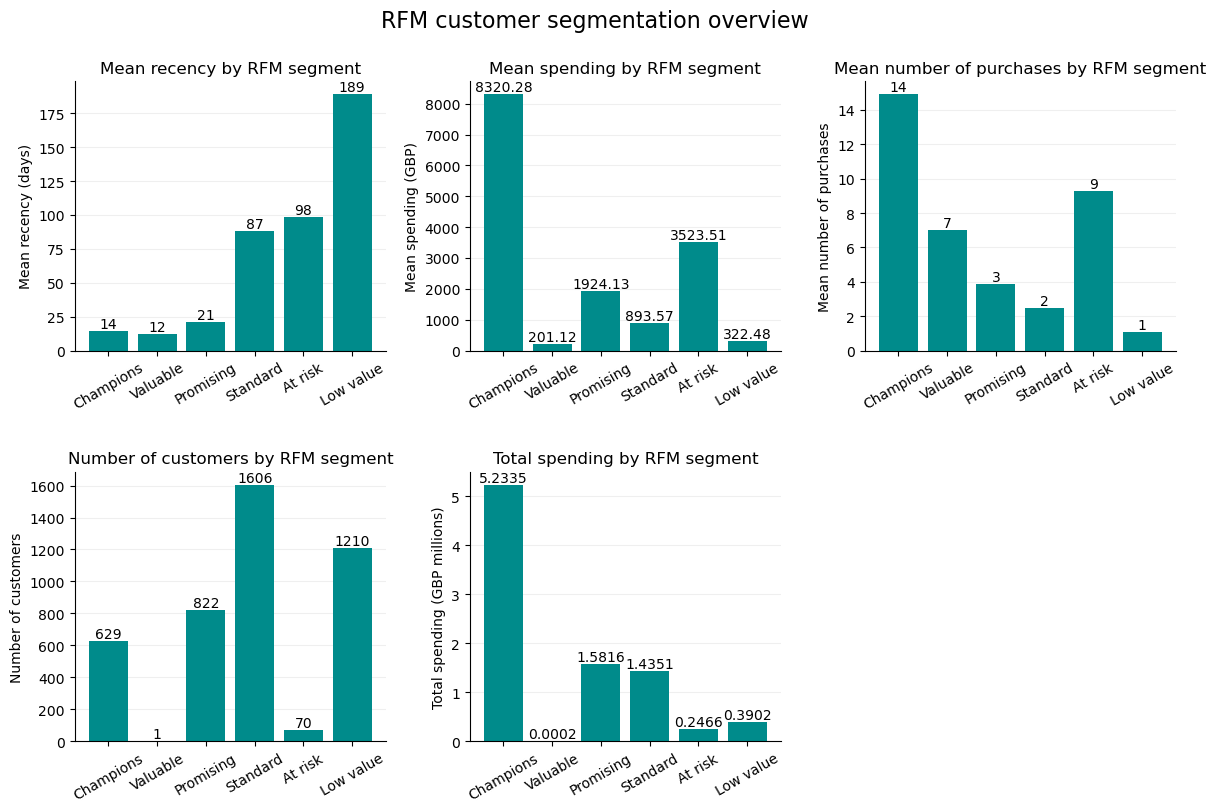

In [110]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
fig.suptitle("RFM customer segmentation overview", fontsize=16,y=1.01)

####################################################################
#Tiempo medio desde la última compra
barras=axes[0,0].bar(
    segments["segment"],
    segments["mean_recency"],
    color="darkcyan"
)

axes[0,0].bar_label(barras,fmt="%d")
axes[0,0].set_ylabel("Mean recency (days)")
axes[0,0].tick_params(axis="x", rotation=30)
axes[0,0].set_title("Mean recency by RFM segment")

####################################################################
#Gasto medio por segmento
barras=axes[0,1].bar(
    segments["segment"],
    segments["mean_spent"],
    color="darkcyan"
)

axes[0,1].bar_label(barras,fmt="%.2f")
axes[0,1].set_ylabel("Mean spending (GBP)")
axes[0,1].tick_params(axis="x", rotation=30)
axes[0,1].set_title("Mean spending by RFM segment")

####################################################################
#Frecuencia media por segmento
barras=axes[0,2].bar(
    segments["segment"],
    segments["mean_freq"],
    color="darkcyan"
)

axes[0,2].bar_label(barras,fmt="%d")
axes[0,2].set_ylabel("Mean number of purchases")
axes[0,2].tick_params(axis="x", rotation=30)
axes[0,2].set_title("Mean number of purchases by RFM segment")

####################################################################
#Número de clientes por segmento
barras=axes[1,0].bar(
    segments["segment"],
    segments["clients"],
    color="darkcyan"
)

axes[1,0].bar_label(barras)
axes[1,0].set_ylabel("Number of customers")
axes[1,0].tick_params(axis="x", rotation=30)
axes[1,0].set_title("Number of customers by RFM segment")

####################################################################
#Gasto total por segmento
segments["total_spent_millions"] = segments["total_spent"] / 1000000

barras = axes[1,1].bar(
    segments["segment"],
    segments["total_spent_millions"],
    color="darkcyan"
)

axes[1,1].bar_label(barras,fmt="%.4f")
axes[1,1].set_ylabel("Total spending (GBP millions)")
axes[1,1].tick_params(axis="x", rotation=30)
axes[1,1].set_title("Total spending by RFM segment")

####################################################################
axes[1,2].axis("off")
for ax in axes.flatten():
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_axisbelow(True)
    ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.subplots_adjust(top=0.92, hspace=0.45)
plt.show()

### Conclusiones:
- Low value representa aproximadamente el 28 % de los clientes. Es el segmento con mayor tiempo medio desde la última compra, menor frecuencia y niveles de gasto medio y total reducidos, lo que refleja clientes poco activos y de bajo valor económico.
- At risk representa solo alrededor del 1,6 % de los clientes, pero presenta una frecuencia media elevada y un gasto medio de aproximadamente 3.524 GBP. Sin embargo, han pasado unos 97 días de media desde su última compra, por lo que se trata de clientes históricamente valiosos cuya actividad reciente ha disminuido.
- Standard es el segmento más numeroso, con aproximadamente el 37 % de los clientes. Presenta una frecuencia media de unas 2 compras y un gasto medio cercano a 894 GBP, representando el comportamiento más habitual de la base de clientes.
- Valuable contiene únicamente un cliente, por lo que no puede considerarse un segmento representativo. Su tamaño residual sugiere que la regla utilizada para definir esta categoría es demasiado restrictiva para este dataset, por lo que sus resultados deben interpretarse con cautela y podría ser conveniente integrarlo en otro segmento en una revisión posterior del modelo.
- Promising concentra aproximadamente el 19 % de los clientes. Presenta compras recientes (unos 20 días de recency media) y un gasto relevante, aunque su frecuencia es bastante inferior a la de Champions, lo que indica potencial para aumentar su recurrencia.
- Champions representa aproximadamente el 14,5 % de los clientes y concentra los mejores indicadores: solo unos 13 días desde la última compra, la mayor frecuencia de compra y los mayores niveles de gasto medio y total. Es el segmento con mayor contribución económica.
    
### Acciones propuestas:
- Champions: prioridad de retención. Mantener su satisfacción y recurrencia mediante beneficios, atención preferente o campañas dirigidas, porque perderlos tendría un impacto económico importante.
- Promising: intentar aumentar su frecuencia de compra y evolucionarlos hacia Champions.
- At risk: prioridad de reactivación. Aunque son pocos, su gasto y frecuencia históricos son elevados; recuperar una parte de estos clientes puede ser más rentable que intentar reactivar masivamente a Low value.

### Comentario final

La segmentación utilizada en este proyecto se diseñó con fines prácticos para aplicar y analizar un modelo RFM completo. Algunas categorías podrían refinarse en una iteración posterior. Por ejemplo, el segmento Valuable contiene muy pocos clientes y podría integrarse en una categoría próxima, mientras que Standard agrupa perfiles intermedios relativamente diversos. Un análisis más exhaustivo podría optimizar las reglas de segmentación para obtener grupos más equilibrados y homogéneos.

No obstante, este refinamiento queda fuera del alcance del proyecto, cuyo objetivo principal es practicar el proceso completo de análisis RFM: preparación de datos, construcción de métricas, scoring, segmentación, visualización e interpretación de resultados.